# Финальный проект: интернет-магазин "Подарочек"

### 1. Импорт библиотек, загрузка и первичная обработка данных

In [153]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [155]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\dry\appdata\local\programs\python\python310\lib\site-packages (3.10.3)




[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [149]:
pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [150]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [151]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats as st
import plotly.express as px

In [4]:
# Производим загрузку датасета для начала анализа
df_orig = pd.read_csv('http://code.s3.yandex.net/datasets/gift.csv', sep = ',')
df_text_orig = pd.read_csv('https://code.s3.yandex.net/python-for-analytics/gift_entry.csv', sep = ';')
# df_orig = pd.read_csv('gift.csv', sep = ',')
# df_text_orig = pd.read_csv('gift_entry.csv', sep = ';')

In [5]:
# Проверяем, что разделитель выбран корректно
df_orig.head(1)

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id
0,12/01/2018 08:26,3031,2150,6,339,740,891,28


In [6]:
df_text_orig.sample(1)

,entry_id,entry
1044,1044,ваза для фруктов из гравированного стекла Jardin


In [7]:
# Тут я делаю копию исходных данных, 
# чтобы в случае необходимости отката датафрейма к изначальной версии, не загружать заново файлы
df_raw = df_orig.copy()
df_text = df_text_orig.copy()

#### 1.1 Приступим к работе с датафреймом df_raw

После того как данные загружены, можно переходить к их рассмотрению.  
Начнем с датасета df_raw. Исследуем из чего он состоит

In [8]:
# Вывод инфомации о количестве строк, типе данных и названиях столбцов
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356940 entries, 0 to 356939
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   entry_date   356940 non-null  object
 1   order_id     356940 non-null  int64 
 2   customer_id  356940 non-null  int64 
 3   quantity     356940 non-null  int64 
 4   price        356940 non-null  int64 
 5   name_clust   356940 non-null  int64 
 6   entry_id     356940 non-null  int64 
 7   country_id   356940 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 21.8+ MB


Обращаем внимание, что столбец entry_date в формате object, что говорит о его некорректном формате.  
Приведем его к формату даты и времени.

In [9]:
# Перевод столбца entry_date к формату времени
df_raw['entry_date'] = pd.to_datetime(df_raw['entry_date'], format='%d/%m/%Y %H:%M')

In [10]:
# Аналогично выводим информацию о втором датафрейме
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356940 entries, 0 to 356939
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   entry_date   356940 non-null  datetime64[ns]
 1   order_id     356940 non-null  int64         
 2   customer_id  356940 non-null  int64         
 3   quantity     356940 non-null  int64         
 4   price        356940 non-null  int64         
 5   name_clust   356940 non-null  int64         
 6   entry_id     356940 non-null  int64         
 7   country_id   356940 non-null  int64         
dtypes: datetime64[ns](1), int64(7)
memory usage: 21.8 MB


In [11]:
# исследуем датафрейм на наличие пропусков
df_raw.isna().sum()

entry_date     0
order_id       0
customer_id    0
quantity       0
price          0
name_clust     0
entry_id       0
country_id     0
dtype: int64

In [12]:
# исследуем датафрейм на наличие дубликатов
# Мы видели, что типы столбцов в этих данных это либо дата, либо число, неявных дубликатов здесь быть не может
df_raw.duplicated().sum()

np.int64(3573)

In [13]:
# Проверим какую долю составляют дубликаты
print(f'Доля дубликатов составляет {round(df_raw.duplicated().sum()* 100/ df_raw.shape[0], 2)}%')

Доля дубликатов составляет 1.0%


In [14]:
# Удаляем дубликаты
df_raw = df_raw.drop_duplicates()
df_raw.shape[0]

353367

В ходе работы с набором данных df был выявлен 1% дубликатов.  
Повторения могут быть следствием того, что человек заказал что-то и решил тут же вдогонку повторить заказ. Но также это может быть следствием ошибки при заказе (актуально для онлайн магазинов).
    
Я принимаю решение удалить пропуски, чтобы, в случае ошибок в данных, не завышать продажи.

#### 1.2 Перейдем к работе с датафреймом df_text

In [15]:
# Посмотрим на количество строк и типы данных
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   entry_id  2917 non-null   int64 
 1   entry     2916 non-null   object
dtypes: int64(1), object(1)
memory usage: 45.7+ KB


In [16]:
# На предыдушей стадии было обнаружено пропущенное значение в одной стоке, посмотрим на него
df_text[df_text['entry'] != df_text['entry']]

,entry_id,entry
0,0,NaN


Пропущено название товара с id равным 0. Можно предположить, что это просто наследие любителей нумеровать списки с нуля.  
Посмотрим, есть ли такой id товара в df_raw

In [17]:
# Исследуем каким набором значений в разных столбцах предствалено подозрительное значение 0 в id товара
df_raw[df_raw['entry_id'] == 0].nunique()

entry_date     1174
order_id       1509
customer_id       1
quantity        297
price             1
name_clust        1
entry_id          1
country_id        1
dtype: int64

In [18]:
df_raw[df_raw['entry_id'] == 0]['price'].sum()

np.int64(0)

Оказывается, entry_id равный 0 выступает своего рода заглушкой в заказах с нулевой стоимостью и только из одного региона.  
Перезапишим эту строку, при дальнейшем объединении сделаем так, чтобы те записи, в которых должен был стоять этот entry_id, получили особое название товара

In [19]:
# Присвоение вместо nan человечесткого названия
df_text['entry'] = df_text['entry'].fillna('отсутствует название')

Проверим наличие дубликатов, но перед этим приведем текстовые поля к единому формату, чтобы избежать появления неявных дубликатов.

In [20]:
# Приведение к нижнему регистру
df_text['entry'] = df_text['entry'].str.lower()
# Удаление нижних пробелов
df_text['entry'] = df_text['entry'].str.strip()

# Я знаю, что это можно было бы сделать одной строкой, 
# но в целях отладки и проверки каждого типа предобработки поотдельности, решил их разделить

In [21]:
df_text[df_text['entry'].duplicated(keep = False)]

,entry_id,entry
757,757,форма для выпечки шоколадных кексов
764,764,форма для выпечки шоколадных кексов
819,819,"шкатулка для безделушек марии-антуанетты, золотая"
2778,2778,форма для выпечки шоколадных кексов
2869,2869,"шкатулка для безделушек марии-антуанетты, золотая"


Есть дубликаты в названиях. Это может быть вызвано тем, что описание составлено недостаточно подробно для выделения тонких различий и это на самом деле товары разные. Либо один товар продавался в разное время по разным ценам.

Посмотрим на стоимость товаров-дубликатов

In [22]:
duplicated_ids = df_text[df_text['entry'].duplicated(keep = False)]['entry_id'].to_list()
for id in duplicated_ids:
    list = df_raw[df_raw['entry_id'] == id]['price'].unique()
    print(f'{id}: {list}')


757: [255 506 496 210 595]
764: [255]
819: [1250]
2778: [255]
2869: [1250 1115  650  300  150  100]


Тут явно видно, что форма для выпечки в двух из трех случаем имеет стоимость 255, а под id 757 скрывается аж 5 разных цен. То же и для шкатулки: есть цена 1250 для id 819 и она же для второго, но помимо базовой цены есть еще 5 вариаций. 

Посмотрим на даты покупок этих товаров и поймем есть ли корреляция между временем и ценой.

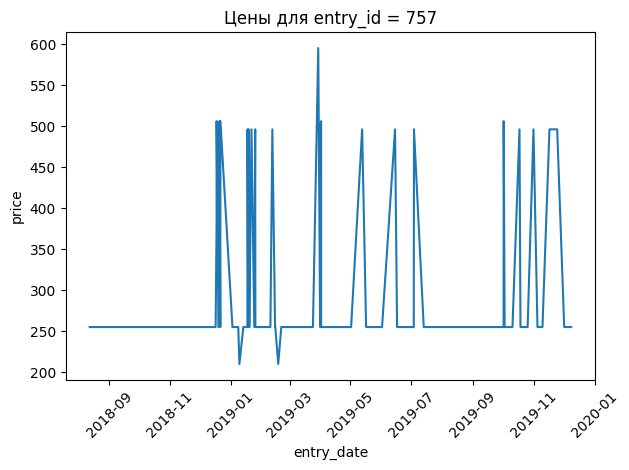

In [23]:
# Рисуем графики зависимости стоимости конкретного товара от времени
data_subset_757 = df_raw.loc[df_raw['entry_id'] == 757]

sns.lineplot(data = data_subset_757, y = 'price', x = 'entry_date')
plt.title('Цены для entry_id = 757')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

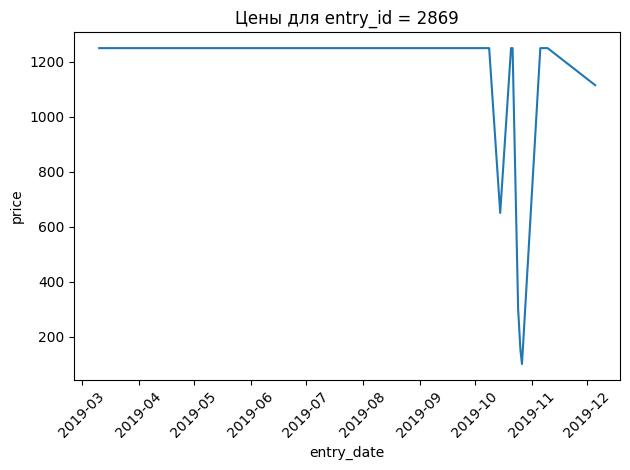

In [24]:
data_subset_2869 = df_raw.loc[df_raw['entry_id'] == 2869]

sns.lineplot(data = data_subset_2869, y = 'price', x = 'entry_date')
plt.title('Цены для entry_id = 2869')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Для обоих подозрительных id нет явной зависимости (график был бы ступенчатый с плато стоимости) -- цена скачет. Может это вызвано скидками, но мы про них ничего не знаем. Для нас самое главное -- чтобы не было конфликта между id.  

Оставим эти записи как они есть.

In [25]:
# Проверим есть ли такие id товара, для которых нет названия
missing = df_raw[~df_raw['entry_id'].isin(df_text['entry_id'])]
print(f"Нет в правой таблице: {len(missing)} строк")

Нет в правой таблице: 0 строк


Все номера товаров имеют подпись, переходим к объединению

In [26]:
df_merged = df_raw.merge(df_text, on = 'entry_id', how = 'left')

In [27]:
# Опять же копируем, чтобы не портить данные
df = df_merged.copy()

### 2. Предобработка данных

Перейдем к обработке значений в объединенном датафрейме.  
Рассмотрим как устроены столбцы price и quantity

#### 2.1 price


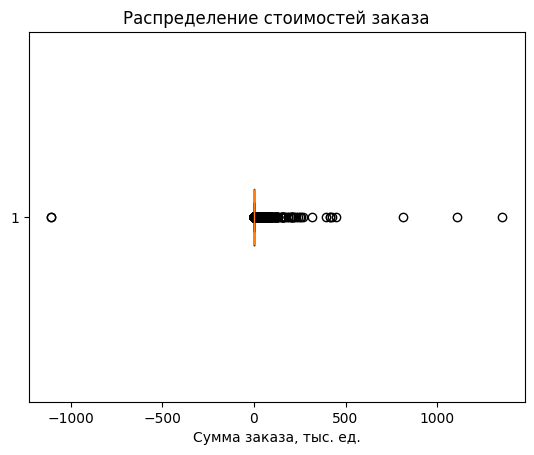

In [28]:
# Построение ящика с усами для анализа стоимостей заказа
plt.boxplot(x = df['price']/1000, vert = False)
plt.xlabel('Сумма заказа, тыс. ед.')
plt.title('Распределение стоимостей заказа')
plt.show()

In [29]:
# На этом этапе мы и отсеяли те товары, для которых меняли entry на "отсутствует название"
df = df[df['price'] > 0]

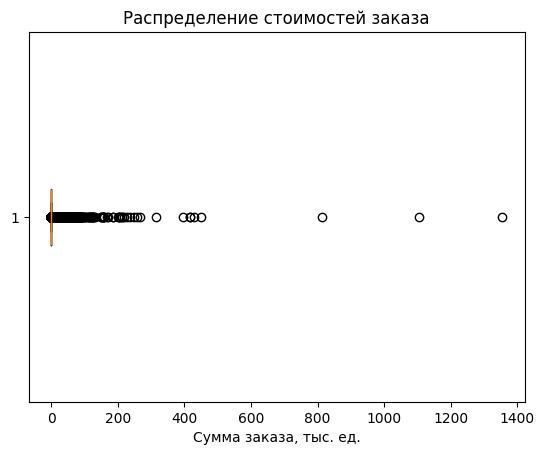

In [30]:
# Построение ящика с усами для анализа стоимостей заказа уже без нулевых значений
plt.boxplot(x = df['price']/1000, vert = False)
plt.xlabel('Сумма заказа, тыс. ед.')
plt.title('Распределение стоимостей заказа')
plt.show()

Выбросы по-прежнему остаются, но картина уже выглядит гораздо более приемлемо.  

Продолжим работу со столбцом. Рассмотрим названия наиболее дорогих покупок.

In [31]:
df[df['price'] > df['price'].quantile(0.999)]['entry'].unique()

array(['дотком, почтовые расходы', 'винтажный красный кухонный шкаф',
       'руководство', 'комиссия амазон', 'старинный синий кухонный шкаф',
       'почтовые расходы', 'корректировка безнадежный долг'], dtype=object)

Видим, что среди дорогих покупок присутствуют не товары, а расходы, связанные с деятельностью магазина, эти записи будут искажать резутьтаты анализа, так как напрямую не относятся к покупкам частных лиц.  

Удалим их.

In [32]:
entries_to_drop = ['дотком, почтовые расходы', 'комиссия амазон', 'почтовые расходы', 'корректировка безнадежный долг']
df_wo_susp_entries = df.query('entry not in @entries_to_drop')

# Снова посмотрим на самые дорогие товары
df_wo_susp_entries[df_wo_susp_entries['price'] > df_wo_susp_entries['price'].quantile(0.999)]['entry'].unique()

array(['буфет с семнадцатью ящиками в деревенском стиле',
       'органайзер для кухни с классной доской',
       'винтажный красный кухонный шкаф', 'шкаф для прихожей с 3 ящиками',
       'набор/4 белых кубика для хранения в стиле ретро',
       'шоколадный плед из искусственного меха', 'руководство',
       'перевозка', 'двойное кресло античный белый металл',
       'старинный синий кухонный шкаф',
       'комод из натурального дерева с 20 ящиками',
       'школьная парта и стул', 'декоративный подвесной стеллаж',
       'штампованный металлический табурет medina', 'люстра золушки',
       'комод с 7 ящиками ma campagne',
       'серебряная люстра в стиле рококо',
       'стальной стол прямоугольной формы в форме сердца кремового цвета',
       'шкаф в форме сердца с тиснением во французском стиле',
       'стальной сладкий крем для круглого стола',
       'одеяло цвета слоновой кости с вышивкой',
       'настенное зеркало в стиле рококо белое',
       'настенные часы ботанического с

Также среди кандидатов на удаление был товар "руководство". Можно подумать, что какие-то операции, связанные с управляющими магазина или же некое руководство по чему-то. Посмотрим на строки с этим товаром.

In [33]:
df_wo_susp_entries[df_wo_susp_entries['entry'] == 'руководство']['customer_id'].unique()

array([3726,   -1, 5277, 2938, 3673, 7252, 4106, 4111, 4118, 2932, 2777,
       2080, 6910, 4445, 2106, 2806, 2308, 3275, 2608, 1884, 2159, 3186,
       4954, 4281, 2189, 3209, 2391, 1882, 3096, 4471, 3790, 4203, 6826,
       2420, 6801, 4115, 2157, 2470, 5394, 2677, 6579, 5954, 7648, 5430,
       4709, 4166, 4977, 7076, 3229, 2685, 6292, 7151, 5538, 3489, 6760,
       5590, 3212, 5473, 5457, 3040, 6816, 7256, 6737, 7331, 4995, 2060,
       4133, 4065, 3652, 6779, 6189, 3601, 3271, 3072, 2551, 1717, 2025,
       3035, 4109, 6363, 3194, 4204, 4326, 7243, 2663, 4967, 7316, 6768,
       2243, 5377, 6950, 2127, 2478, 3795, 5333, 5539, 2241, 4701, 2163,
       2200, 7529, 6699, 7381, 4666, 4080, 3717, 5204, 4144, 2604, 4598,
       4996, 2250, 6436, 4198, 4468, 5544, 2596, 4419, 5466, 2662, 2757,
       2135, 2051, 1913, 2635, 2154, 5231, 3631, 4112, 5554, 4974, 3331,
       4099, 4451, 6236, 5347, 6833, 4498, 2043, 3626, 7077, 1874, 6776,
       2411, 6792, 5024, 4518, 2229, 6190, 4887, 72

Набор покупателей предствлен широким спектром id, что скорее горорит в пользу второй версии происхождения этого товара. Оставим его.

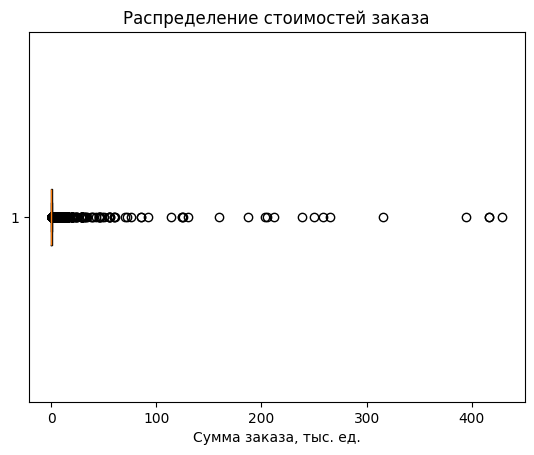

In [34]:
# Построение ящика с усами для анализа стоимостей заказа
plt.boxplot(x = df_wo_susp_entries['price']/1000, vert = False)
plt.xlabel('Сумма заказа, тыс. ед.')
plt.title('Распределение стоимостей заказа')
plt.show()

Выбросы все равно остались, но мы видели, что это действительно дорогие настоящие товары.

In [35]:
# На этом этапе мы зафиксировали df уже без дорогих товаров, не относящихся к покупкам обычными людьми
df = df_wo_susp_entries.copy()

#### 2.2 quantity


In [36]:
df['quantity'].describe()

count    349515.000000
mean         10.561527
std         141.700601
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: quantity, dtype: float64

Видим, что среднее значительно больше медианы, значит есть выбросы в больших положительных значениях.  

Построим ящики с усами, чтобы посмотреть на данные поближе.

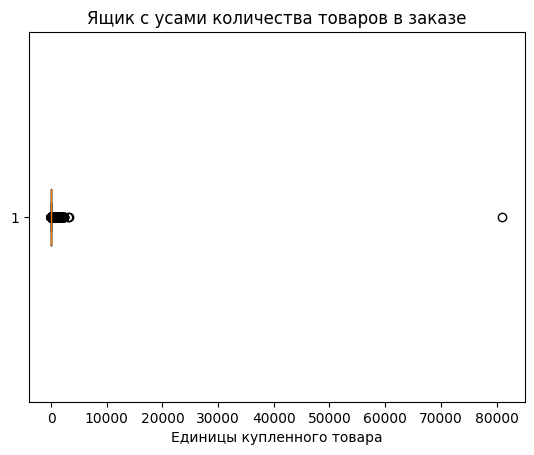

In [37]:
plt.boxplot(x = 'quantity', data = df, vert = False)
plt.title('Ящик с усами количества товаров в заказе')
plt.xlabel('Единицы купленного товара')
plt.show()

Видим один единственный выброс в районе 80 000 единиц

In [38]:
df[df['quantity'] > 10_000]

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id,entry
352335,2019-09-12 09:15:00,48149,3554,80995,208,325,2204,28,"поделка из бумаги, маленькая птичка"


Кому-то потребовалось 80995 бумажных птичек, верится слабо.

In [39]:
# Удалим строку с аномально большим количеством единиц товара
df = df[df['quantity'] < 10_000]

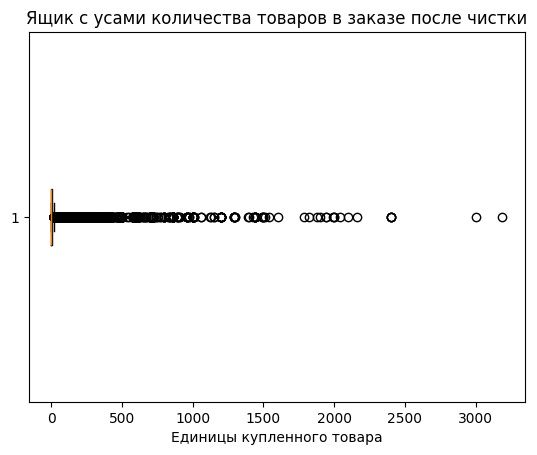

In [40]:
# ПОстроим распределение количества товаров в заказе после удаления строк
plt.boxplot(x = 'quantity', data = df, vert = False)
plt.title('Ящик с усами количества товаров в заказе после чистки')
plt.xlabel('Единицы купленного товара')
plt.show()

После очистки двух столбцов от явных ошибок, перейдем к рассмотрению прочих.

#### 2.3 Обработка прочих столбцов

In [41]:
df.describe()

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id
count,349514,349514.000000,349514.000000,349514.000000,349514.000000,349514.000000,349514.000000,349514.000000
mean,2019-06-16 16:27:30.697310976,26701.398880,3495.953621,10.329821,336.974453,473.338519,1525.751689,26.784386
min,2018-01-12 08:26:00,3031.000000,-1.000000,1.000000,6.000000,0.000000,1.000000,0.000000
25%,2019-03-24 11:43:00,14854.000000,-1.000000,1.000000,125.000000,248.000000,900.000000,28.000000
50%,2019-07-04 10:10:00,27391.500000,3640.000000,3.000000,208.000000,451.000000,1561.000000,28.000000
75%,2019-10-05 10:34:00,38511.000000,5633.000000,10.000000,413.000000,706.000000,2223.000000,28.000000
max,2019-12-10 17:19:00,48253.000000,7653.000000,3186.000000,428763.000000,929.000000,2916.000000,29.000000
std,NaN,13374.901235,2535.682624,36.255237,2052.873048,256.093230,828.173716,4.913241


1) Столбец order_id выглядит корректным, среднее близко к медиане, выбросов нет.  
2) В customer_id есть странные значения -1 и их почти около четверти. Здесь среднее тоже близко к медиане, изучим этот столбец подробнее чуть-чуть попозже.  
3) quantity и price были обработаны ранее  
4) entry_id тоже уже частично рассматривался, в нем нет дубликатов, но держим в голове странное поведение цен для ряда товаров.  
5) country_id тут есть странное значение 0, обратим на него внимание, остальные значения, по всей видимости, около 28-29.


##### 2.3.1 customer_id


In [42]:
# Сразу перейдем к рассмотрению строк с id пользователя равным -1
n_susp_id = df[df['customer_id'] == -1].shape[0]
print(f'Количество строк с customer_id -1 {n_susp_id}, это {round(n_susp_id * 100 / df.shape[0], 2)}% оставшихся данных')

Количество строк с customer_id -1 89544, это 25.62% оставшихся данных


Посмотрим на количество дат совершения покупки для таких пользователей.

In [43]:
df[df['customer_id'] == -1]['entry_date'].dt.date.unique().shape[0]

269

269 дней это слишком много для сбоя в работе сервиса.  
25% данных не может быть занято одним конкретным клиентом. Возможно, это неавторизованные пользователи.  

Придется не учитывать эти данные при расчете величин, так как если их оставить, будут испорчены данные, получаемые усреднением.  

Для ряда параметров (dau, mau) все эти пользователи схлопнутся в одного, при расчете средней стоимости заказа на пользователя, этот один "мега"-пользователь сильно повлияет на результаты. 

Бывают случаи, когда надо отдельно рассмотреть неавторизованных пользователей, но в данной работе этого не требуется.

In [44]:
df = df[df['customer_id'] != -1]

##### 2.3.2 country_id


In [45]:
df.groupby('country_id')['order_id'].nunique().reset_index()

,country_id,order_id
0,0,54
1,1,17
2,2,2
3,3,97
4,4,1
5,5,379
6,6,446
7,7,5
8,9,7
9,10,4


Мы видим, что country_id представлено значениями от 0 до 29, наиболее часто встечающееся значение -- 28. Ряд стран представлен единственным клиентом, возможно, менеджерам магазина стоит задуматься над расширением рынков.

Основное рассмотрение столбцов закончено, подведем итоги очистки.

In [46]:
print(f'Изначально данные содержали {df_orig.shape[0]} строк \n')
print(f'Осталось {df.shape[0]} строк, что составляет {round(df.shape[0] * 100 / df_orig.shape[0], 1)}% (удалили {round(100-df.shape[0] * 100 / df_orig.shape[0], 1)}%)')

Изначально данные содержали 356940 строк 

Осталось 259970 строк, что составляет 72.8% (удалили 27.2%)


В процессе анализы было потеряно 27% процентов, да, это много, но большая часть из них это данные, которые невозможно корректно проанализировать и разделить (неавторизованные пользователи).  
Зато теперь мы можем быть уверены, что данные готовы к дальнейшей работе.

##### 2.3.3 Анализ полноты данных


In [47]:
# Копируем исходные данные, чтобы опять же не поритить то, что уже получили.
# Главное не забывать в конце каждого успешного блока (в чистовой работе вы других и не встретите :) ) перезаписывать df
df_time = df.copy()

In [48]:
# Создадим словарь с количеством дней в месяце
month_days = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12:31}

df_time['date_only'] = df_time['entry_date'].dt.date # дата, чтобы избавиться от времени
df_time['month'] = df_time['entry_date'].dt.month # только номер месяца
df_time['year'] = df_time['entry_date'].dt.year # только год

# Группироуем и сохраняем количество активных дат
active_days_2018 = df_time[df_time['year'] == 2018].sort_values('month').groupby('month')['date_only'].nunique()
active_days_2019 = df_time[df_time['year'] == 2019].sort_values('month').groupby('month')['date_only'].nunique()
unactive_days_2018 = {}
unactive_days_2019 = {}

for month in range(1, 13):
    active = active_days_2018.get(month, 0)
    unactive_days_2018[month] = month_days[month] - active
for month in range(1, 13):
    active = active_days_2019.get(month, 0)
    unactive_days_2019[month] = month_days[month] - active

In [49]:
print("Неактивные дни 2018:")
for month, days in unactive_days_2018.items():
    print(f"  Месяц {month}: {days} дня(ей) без продаж")
print()
print("Неактивные дни 2019:")
for month, days in unactive_days_2019.items():
    print(f"  Месяц {month}: {days} дня(ей) без продаж")

Неактивные дни 2018:
  Месяц 1: 30 дня(ей) без продаж
  Месяц 2: 27 дня(ей) без продаж
  Месяц 3: 30 дня(ей) без продаж
  Месяц 4: 30 дня(ей) без продаж
  Месяц 5: 30 дня(ей) без продаж
  Месяц 6: 29 дня(ей) без продаж
  Месяц 7: 30 дня(ей) без продаж
  Месяц 8: 30 дня(ей) без продаж
  Месяц 9: 29 дня(ей) без продаж
  Месяц 10: 30 дня(ей) без продаж
  Месяц 11: 30 дня(ей) без продаж
  Месяц 12: 20 дня(ей) без продаж

Неактивные дни 2019:
  Месяц 1: 5 дня(ей) без продаж
  Месяц 2: 6 дня(ей) без продаж
  Месяц 3: 5 дня(ей) без продаж
  Месяц 4: 8 дня(ей) без продаж
  Месяц 5: 7 дня(ей) без продаж
  Месяц 6: 3 дня(ей) без продаж
  Месяц 7: 4 дня(ей) без продаж
  Месяц 8: 6 дня(ей) без продаж
  Месяц 9: 4 дня(ей) без продаж
  Месяц 10: 5 дня(ей) без продаж
  Месяц 11: 4 дня(ей) без продаж
  Месяц 12: 23 дня(ей) без продаж


Мы видим, что в 2018 году не меньше 20 дней году в месяце без продаж, это не подходит для анализа. Может быть, магазин тогда толко открылся.  
В 2019 ситуация лучше, за исключением декабря.  

Тогда выберем в качестве корректного периода времени выберем январь-ноябрь 2019 года.

In [50]:
df_time = df_time[(df_time['year'] == 2019) & (df_time['month'] != 12)]

print(f"Период для анализа: с {df_time['date_only'].min()} по {df_time['date_only'].max()}")

Период для анализа: с 2019-01-02 по 2019-11-30


In [51]:
# С датами поколдовали, сохраним результат в рабочий df
df = df_time.copy()

### 3. Расчёт метрик

##### 3.1 Анализ цикличности

In [52]:
# Для красоты отображения переведем номер дня недели в словестную форму
df['week_day'] = df['entry_date'].dt.dayofweek

# Словарь с названиями дней недели
week_days_name = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}

# Сшиваем номер-имя 
df['day_name'] = df['week_day'].map(week_days_name)

# Также выделим час совершения заказа
df['hour'] = df['entry_date'].dt.hour

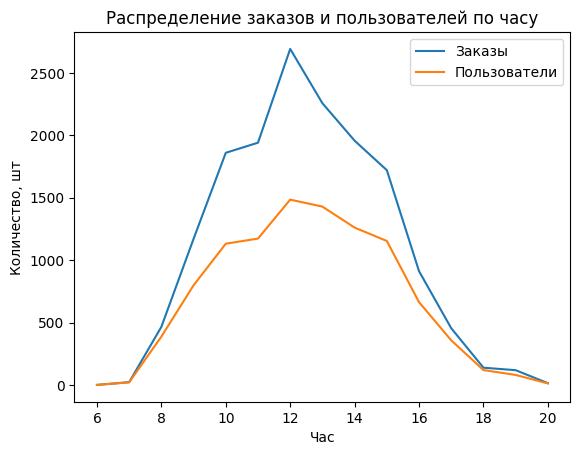

In [53]:
# Создаем отдельный датафрейм для удобного рисования графиков
df_hour_cicle = df.groupby(['hour']).agg({'order_id': 'nunique','customer_id': 'nunique'}).reset_index()

# Нарисуем сразу две линии, чтобы графики были в одном масштабе
sns.lineplot(x = 'hour', y = 'order_id', data = df_hour_cicle, label = 'Заказы')
sns.lineplot(x = 'hour', y = 'customer_id', data = df_hour_cicle, label = 'Пользователи')

plt.title('Распределение заказов и пользователей по часу')
plt.xlabel('Час')
plt.ylabel('Количество, шт')
plt.legend()
plt.show()

Мы видим, что пользователи наиболее активны в дневное время с 10 утра до 15 часов. Ночью (с 21 до 6 утра), по всей видимости, магазин не принимает заказы

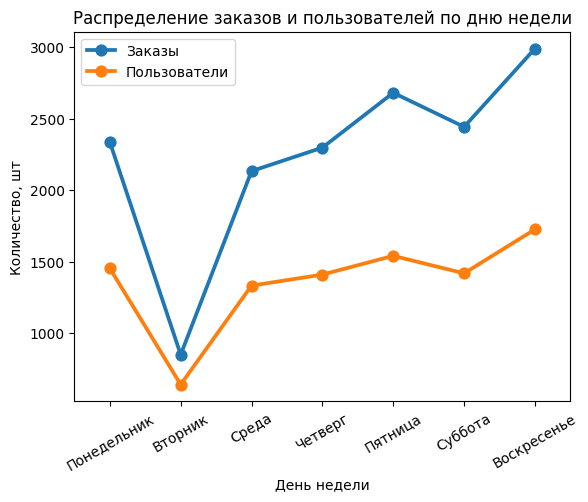

In [54]:
# Создаем вспомогательный датафрейм для отображения активности по дняи недели
df_d_w_cicle = df.groupby(['day_name']).agg({'order_id': 'nunique','customer_id': 'nunique'}).reset_index()

# Также рисуем две кривые
sns.pointplot(
            x = 'day_name',
            y = 'order_id', 
            data = df_d_w_cicle,
            order = week_days_name.values(),
            label = 'Заказы'
            )

sns.pointplot(
            x = 'day_name',
            y = 'customer_id', 
            data = df_d_w_cicle,
            order = week_days_name.values(),
            label = 'Пользователи'
            )

plt.title('Распределение заказов и пользователей по дню недели')
plt.xlabel('День недели')
plt.ylabel('Количество, шт')
plt.xticks(rotation = 30)
plt.legend()
plt.show()

Распределение активности по дням недели имеет более сложную форму.  

Видно, что после провала во вторник активность почти монотонно растет к выходным. В воскоресенье наблюдается недельных максимум. Вторничное и менее заметное субботнее снижение активности может быть следствием того, что после очень активных заказов в воскресенье и понедельник, люди собираются с силами и думают про новые праздники. 

"+" можно предположить, что  личные празники устраивают скорее на выходных или в пятницу, а корпоративные в пятницу или понедельник. Соответсвенно, чтобы получить товары в понедельник, надо закать их в воскресенье, а в пятницу можно и день в день заказать и забрать.

##### 3.2.1 Расчет средней выручки с клиента в день по месяцам

Это как раз тот случай, когда лучше не учитывать неавторизованных клиентов

In [55]:
df_aut = df.copy()

# Делаем группировку по месяцу, чтобы определить средние показатели
df_aut = df_aut.groupby('month').agg(
    {'price': 'sum',
    'customer_id': 'nunique'}
    ).reset_index()

In [56]:
# Подтягиваем количество дней в месяце
df_aut['day_in_month'] = df_aut['month'].map(month_days)

In [57]:
# Считаем среднюю сумму заказа: делим полную сумму за месяц на количество пользователей -> 
# среднемесячный чек и делим еще на количество дней в месяце -> 
# получаем средне дневной чек на покупателя
df_aut['mean_sum'] = df_aut['price']/(df_aut['customer_id'] * df_aut['day_in_month'])

In [58]:
# Добавим название месяцов для красоты вывода графиков
month_names = {
    1: 'Январь', 2: 'Февраль',
    3: 'Март', 4: 'Апрель',
    5: 'Май', 6: 'Июнь',
    7: 'Июль', 8: 'Август',
    9: 'Сентябрь', 10: 'Октябрь',
    11: 'Ноябрь'}

# Сшиваем номер-название
df_aut['month_name'] = df_aut['month'].map(month_names)

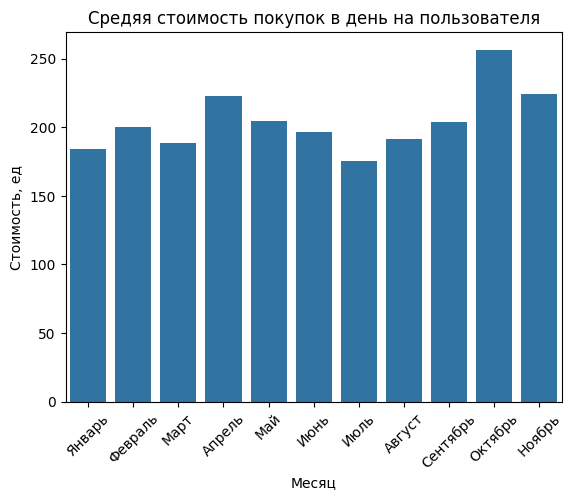

In [59]:
# Строим график
sns.barplot(x = 'month_name', y = 'mean_sum', data = df_aut, order = month_names.values())
plt.xticks(rotation = 45)
plt.xlabel('Месяц')
plt.ylabel('Стоимость, ед')
plt.title('Средяя стоимость покупок в день на пользователя')
plt.show()

#### Анализ
+ На графике видно снижение средней стоимости покупки в день в летние месяцы. Это может быть связано с тем, что люди копят на отпусе и уезжают, покупка подарков не в приоритете в этот период. 
+ В январе также наблюдается низкий относительно других месяцев средний чек, можно предположить (не до конца достоверно, так как нет данных за декабрь), что после новогодних праздников люди берут "подарковый" детокс.

#### Предложения

+ Чтобы избежать провалов в летний период можно попробовать запускать акции и рекламу, связанные с летними праздниками:  
1 июня - день защиты детей;  
10 июня - всемирный день мороженого;  
20 июля - международный день шахмат;  
10 августа - международный день биодизеля.. :)    

+ А январское затишье можно так и оставить, всем нужен передых или обратить внимание покупателей на товары для спокойного отдыха, уюта

Построим график зависимости количества активных клиентов по месяцам

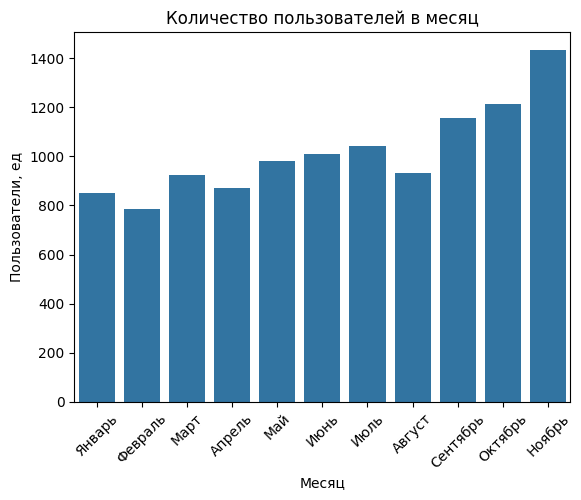

In [60]:
sns.barplot(x = 'month_name', y = 'customer_id', data = df_aut, order = month_names.values())
plt.xticks(rotation = 45)
plt.xlabel('Месяц')
plt.ylabel('Пользователи, ед')
plt.title('Количество пользователей в месяц')
plt.show()

На графике мы видим не монотонный рост количества пользователей, совершивших заказ. Это может быть вызвано как тем, что магазин развивается и расширяет клиентскую базу.  
Снижение в августе может быть вызвано, как обсуждлось выше, отъездом многих людей в отпуск.

##### 3.2.2 Расчет sticky-factor для второго и третьего квартала 2019 года

In [61]:
# Создадим пользовательскую функцию, рассчитывающую стики фактор
#  по каждому месяцу в рамках указанного периода и средний по периоду.
   
def calc_sticky(df, months):
    """
    Рассчитывает средний Sticky Factor за указанные месяцы
    """
    df_period = df[df['month'].isin(months)]
    monthly_sticky = {}
    
    for month in months:
        df_month = df_period[df_period['month'] == month]
        mau = df_month['customer_id'].nunique()
        dau = df_month.groupby('date_only')['customer_id'].nunique().mean()
        if mau > 0:
            monthly_sticky[month] = float(round(dau / mau, 4))

    return monthly_sticky, sum(monthly_sticky.values()) / len(monthly_sticky) if monthly_sticky else 0

In [62]:
# Второй квартал 
q2_dict, sticky_q2 = calc_sticky(df, [4,5,6])

# Третий квартал
q3_dict, sticky_q3 = calc_sticky(df, [7,8,9])

print(f"Sticky Factor второй квартал: {q2_dict}, среднее {sticky_q2:.4f}")
print(f"Sticky Factor третий квартал: {q3_dict}, среднее {sticky_q3:.4f}")

Sticky Factor второй квартал: {4: 0.0586, 5: 0.0548, 6: 0.0484}, среднее 0.0539
Sticky Factor третий квартал: {7: 0.0481, 8: 0.0538, 9: 0.0488}, среднее 0.0502


Мы видим, что sticky factor около 0.05  для 2го и 3го квартала, при чем увеличения не наблюдается.  
Значение около 0.05 означает, что пользователи совершают 1-2 покупки в месяц. Для онлайн магазина это нормальный результат.

##### 3.2.3 Построение профиля клиента

In [63]:
# Сначала посчитаем revenue - сумму строки заказа
df['revenue'] = df['price'] * df['quantity']

# Профиль клиента
customer_profile = df.groupby('customer_id').agg(
    first_order=('entry_date', 'min'),
    last_order=('entry_date', 'max'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_revenue_per_order=('revenue', 'mean'),
    total_items=('quantity', 'sum')
).reset_index()

# Дополнительные метрики
customer_profile['customer_lifetime_days'] = (
    customer_profile['last_order'] - customer_profile['first_order']
).dt.days

customer_profile['avg_check'] = (
    customer_profile['total_revenue'] / customer_profile['total_orders']
)

# Посмотрим на результат
customer_profile.head()

,customer_id,first_order,last_order,total_orders,total_revenue,avg_revenue_per_order,total_items,customer_lifetime_days,avg_check
0,1713,2019-05-22 10:39:00,2019-10-28 09:29:00,2,61114,2350.538462,410,158,30557.000000
1,1717,2019-01-23 14:58:00,2019-11-30 12:59:00,14,148630,262.134039,1058,310,10616.428571
2,1718,2019-02-12 11:43:00,2019-05-08 13:35:00,2,11886,1485.750000,78,85,5943.000000
3,1720,2019-07-03 09:52:00,2019-07-03 09:52:00,1,13290,1898.571429,35,0,13290.000000
4,1722,2019-09-27 11:58:00,2019-09-27 11:58:00,1,12690,2115.000000,38,0,12690.000000


In [64]:
# Поведем разделение на возвратных и не возвратных клиентов
# Если количество заказов > 1 → возвратный
customer_profile['is_returning'] = customer_profile['total_orders'] > 1

In [65]:
# Выбираем показатели для сравнения
metrics = ['total_revenue', 'total_orders', 'avg_check', 'total_items']

comparison = customer_profile.groupby('is_returning')[metrics].mean().round(2)

comparison

,total_revenue,total_orders,avg_check,total_items
is_returning,,,,
False,24245.17,1.00,24245.17,154.85
True,175199.71,5.49,26410.68,1084.65


In [66]:
# Доля возвратных клиентов
returning_share = customer_profile['is_returning'].mean()
print(f"Доля возвратных клиентов: {round(returning_share * 100, 1)}%")

# Во сколько раз возвратные клиенты лучше
for col in metrics:
    ratio = comparison.loc[True, col] / comparison.loc[False, col]
    print(f"Возвратные vs невозвратные - {col}: в {round(ratio,2)} раза выше")

Доля возвратных клиентов: 63.2%
Возвратные vs невозвратные - total_revenue: в 7.23 раза выше
Возвратные vs невозвратные - total_orders: в 5.49 раза выше
Возвратные vs невозвратные - avg_check: в 1.09 раза выше
Возвратные vs невозвратные - total_items: в 7.0 раза выше


Возвратные клиенты составляют 64.8% аудитории и приносят в 7.5 раза больше выручки. Их преимущество в высокой частоте покупок, а не в размере чека (всего +7%).  
Ключевая стратегия: удержание и стимулирование повторных покупок.

### 4. RFM-анализ

In [67]:
df_rfm = df.copy()

# Дата анализа — последний день в данных
analysis_date = df_rfm['entry_date'].max()

# 1. Считаем RFM-метрики по каждому клиенту
rfm = df_rfm.groupby('customer_id').agg(
    # Тут берем для каждого пользователся разность между датой анализа и 
    # максимальной датой совершения покупки (последняя покупка), 
    # получаем сколько дней он не активен
    recency=('entry_date', lambda x: (analysis_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

In [68]:
# 3. Создаём сегменты (3 группы — всё просто)
# Recency и Monetary — через qcut
rfm['r'] = pd.qcut(rfm['recency'], q=3, labels=[3, 2, 1])

In [69]:
rfm['frequency'].describe()

count    4098.000000
mean        3.837970
std         6.083112
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       166.000000
Name: frequency, dtype: float64

In [70]:
# Frequency — ручные границы
rfm['f'] = pd.cut(
    rfm['frequency'], 
    bins=[0, 2, 4, 199], 
    labels=[1, 2, 3],
    right=False
)

In [71]:
rfm['m'] = pd.qcut(rfm['monetary'], q=3, labels=[1, 2, 3])

In [72]:
# 4. Склеиваем сегменты в строку
rfm['rfm_group'] = (
    rfm['r'].astype(str) +
    rfm['f'].astype(str) +
    rfm['m'].astype(str)
)

# 5. Сумма баллов
rfm['rfm_sum'] = (
    rfm['r'].astype(int) +
    rfm['f'].astype(float) +
    rfm['m'].astype(int)
)

# 6. Смотрим на сегменты
rfm_summary = rfm.groupby('rfm_group').agg(
    customers=('customer_id', 'count'),
    avg_rfm_score=('rfm_sum', 'mean')
).reset_index().sort_values('avg_rfm_score', ascending = False)

rfm_summary

,rfm_group,customers,avg_rfm_score
26,333,656,9.0
17,233,341,8.0
23,323,80,8.0
25,332,125,8.0
16,232,98,7.0
14,223,100,7.0
20,313,7,7.0
22,322,215,7.0
8,133,46,7.0
24,331,11,7.0


In [73]:
# Построим график treemap для визуализации результатов RFM сегментации:
fig = px.treemap(rfm_summary, 
                 path=['rfm_group'], # Выбираем RFM-сегменты 
                 values='customers', # Устанавливаем размер - количество покупателей
                 color='avg_rfm_score', # Цвет сегмента будет определять сумма RFM 
                 color_continuous_scale='Sunset',
                 title='RFM сегментация пользователей онлайн магазина')

# Отобразим график:
fig.show() 

#### 4.1 Результаты rfm анализа.

1) Мы видидим, что "золотое ядро" клиектов (сегмент 333, 697 клиентов) - самая ценная аудитория. Необходимо поддерживать их лояльность через программы поощрения, эксклюзивные предложения и качественную поддержку.

2) Второй по численности сегмент (636 человек) наименее ценные на данный момент клиенты: покупают мало, редко и на небольшие суммы (111). Требуется реактивация, в противном случае возможен уход.  

Также помним, что в данных присутствовало почти 25% процентов записей неавторизованных пользователей (сюда они не вошли). Компании стоит задуматься над тем, чтобы сделать какую-то втягивающую акцию, например, за регистрацию и первые 3 заказа в течение последующих 2х месяцев начисление скидочных баллов или иное вознаграждение.

Дальше группы не так четко выделяются по размеру, рекомендации по ним:
3) надежные клиенты с сумманым рейтингом 7-8 (233, 323, 332 и др.) . Для них необходимо развивать программу поощрения за активность, напоминать о праздниках и устраивать распродажи, чтобы они оставались лояльны и, переходили в более высокие группы.  

4) Группы с рейтингом 4-6 покупают менее часто, на средние суммы. Могут быть вовлечены через скидочные промокоды и таргетированные рассылки.

5) Малововлеченные группы: суммарный рейтинг 2-3. Возможно, это уходящие клиенты. Требуется реактивация, иначе они покинут сервис.

### 5. Проверка гипотез

#### 5.1 Сравнение доли возвратных и невозвратных клиентов за второй и третий квартал 2019 года.

Нулевая гипотеза (H0):  
Доля возвратных клиентов во втором квартале 2019 года равна доле возвратных клиентов в третьем квартале 2019 года.

Альтернативная гипотеза (H1):  
Доля возвратных клиентов во втором квартале 2019 года не равна доле возвратных клиентов в третьем квартале 2019 года.


In [74]:
# Считаем возвратных клиентов (сделали >1 заказа)
# Сначала определим по кварталам
df_q2 = df[df['month'].isin([4,5,6])]
df_q3 = df[df['month'].isin([7,8,9])]

# Количество уникальных клиентов и возвратных в каждом квартале
n_q2 = df_q2['customer_id'].nunique()
returning_q2 = df_q2.groupby('customer_id')['order_id'].nunique()
returning_q2 = (returning_q2 > 1).sum()

n_q3 = df_q3['customer_id'].nunique()
returning_q3 = df_q3.groupby('customer_id')['order_id'].nunique()
returning_q3 = (returning_q3 > 1).sum()

# Пропорции
prop_q2 = returning_q2 / n_q2
prop_q3 = returning_q3 / n_q3

print(f"Q2: возвратных {returning_q2} из {n_q2} ({prop_q2:.2%})")
print(f"Q3: возвратных {returning_q3} из {n_q3} ({prop_q3:.2%})")

# Z-тест для пропорций
count = [returning_q2, returning_q3]
nobs = [n_q2, n_q3]
z_stat, p_value = proportions_ztest(count, nobs)

print(f"\nZ-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Отвергаем H0: доли возвратных клиентов статистически значимо различаются")
else:
    print("Не отвергаем H0: различия долей статистически не значимы")

Q2: возвратных 846 из 2015 (41.99%)
Q3: возвратных 935 из 2168 (43.13%)

Z-статистика: -0.7465
P-value: 0.4554
Не отвергаем H0: различия долей статистически не значимы


Различия в доле возвратных клиентов между вторым и третьим кварталами 2019 года статистически не значимы (p = 0.536).  
Уровень повторных покупок остался стабильным.

#### 5.2 Сравнение средних чеков в странах с country_id, равному 3, 6 и 24.

Нулевая гипотеза H0:  
Средние чеки во всех трёх странах (3, 6 и 24) равны между собой.

Альтернативная гипотеза H1:  
Средние чеки различаются хотя бы в одной паре стран.

In [75]:
# Берём данные по трём странам
df_3 = df[df['country_id'] == 3]['revenue']
df_6 = df[df['country_id'] == 6]['revenue']
df_24 = df[df['country_id'] == 24]['revenue']

alpha = 0.05
n_comparisons = 3  # три пары: (3,6), (3,24), (6,24)
alpha_i = alpha / n_comparisons

print(f"Исходный alpha: {alpha}")
print(f"Поправка Бонферрони: alpha_i = {alpha_i:.5f}\n")

# Попарные t-тесты
t_stat_3_6, p_3_6 = st.ttest_ind(df_3, df_6, equal_var=False, alternative = 'two-sided')
t_stat_3_24, p_3_24 = st.ttest_ind(df_3, df_24, equal_var=False, alternative = 'two-sided')
t_stat_6_24, p_6_24 = st.ttest_ind(df_6, df_24, equal_var=False, alternative = 'two-sided')

print(f"Страны 3 vs 6: p-value = {p_3_6:.5f} → {'значимо' if p_3_6 < alpha_i else 'не значимо'}")
print(f"Страны 3 vs 24: p-value = {p_3_24:.5f} → {'значимо' if p_3_24 < alpha_i else 'не значимо'}")
print(f"Страны 6 vs 24: p-value = {p_6_24:.5f} → {'значимо' if p_6_24 < alpha_i else 'не значимо'}")

# Общий вывод
if min(p_3_6, p_3_24, p_6_24) < alpha_i:
    print("\nОтвергаем H0: средние чеки в странах различаются")
else:
    print("\nНе отвергаем H0: нет оснований считать, что чеки различаются")

Исходный alpha: 0.05
Поправка Бонферрони: alpha_i = 0.01667

Страны 3 vs 6: p-value = 0.00000 → значимо
Страны 3 vs 24: p-value = 0.00000 → значимо
Страны 6 vs 24: p-value = 0.00000 → значимо

Отвергаем H0: средние чеки в странах различаются


На основе попарного t-теста с поправкой Бонферрони (alpha_i = 0.0167) установлено, что средние чеки статистически значимо различаются между всеми тремя странами.  
Таким образом, нулевая гипотеза отвергается.

#### 5.3 Сравнение средних чеков в выходные и будние дни

Нулевая гипотеза (H0):  
Среднее количество заказов в выходные дни меньше или равно среднему количеству заказов в будние дни.

Альтернативная гипотеза (H1):  
Среднее количество заказов в выходные дни больше, чем в будние дни.

In [76]:
# Добавляем колонку с типом дня
df['is_weekend'] = df['week_day'] >= 5  # суббота(5) и воскресенье(6)

In [77]:
# Группируем по дням и считаем заказы
daily_orders = df.groupby('date_only').agg(
    total_orders=('order_id', 'nunique'),
    is_weekend=('is_weekend', 'first')
).reset_index()

# Разделяем на будни и выходные
weekday_orders = daily_orders[~daily_orders['is_weekend']]['total_orders']
weekend_orders = daily_orders[daily_orders['is_weekend']]['total_orders']

print(f"Будни: среднее заказов в день = {round(weekday_orders.mean(), 2)}")
print(f"Выходные: среднее заказов в день = {round(weekend_orders.mean(), 2)}")

# alternative='less' потому что проверяем, что в будние заказов меньше, чем в выходные
t_stat, p_value = st.ttest_ind(weekday_orders, weekend_orders, 
                               equal_var=False, alternative='less')

print(f"P-value (односторонний): {round(p_value, 2)}")
print()
if p_value < 0.05:
    print("Отвергаем H0: На выходных заказов статистически значимо больше")
else:
    print("Не отвергаем H0")

Будни: среднее заказов в день = 54.48
Выходные: среднее заказов в день = 61.72
P-value (односторонний): 0.01

Отвергаем H0: На выходных заказов статистически значимо больше


Выходные дни демонстрируют более высокую покупательскую активность. Рекомендуется усилить маркетинговую активность в субботу и воскресенье.

-------------------------------------------------------------------------------------------------------------------------

### 6. Выводы

##### 6.1 Подготовка данных

На первом этапе были обработаны пропуски, скорректированы типы данных и удалены аномальные значения. Также было учтено наличие неавторизованных пользователей, что позволило более корректно интерпретировать результаты анализа клиентской базы.

##### 6.2 Поведение покупателей

Анализ показал, что основную ценность для бизнеса формируют возвратные клиенты:

+ возвратные пользователи составляют около 64.8% аудитории;
именно они приносят основную часть выручки — примерно в 7.5 раза больше, чем новые клиенты;
ключевое отличие связано не столько с размером среднего чека, сколько с высокой частотой покупок.

Это означает, что для интернет-магазина наиболее выгодной стратегией является не только привлечение новых клиентов, но прежде всего удержание существующих покупателей и стимулирование повторных заказов.

##### 6.3 RFM-анализ

Сегментация клиентов позволила выделить несколько важных групп аудитории:

Крупные сегменты:

+ сегмент 333 («золотое ядро») — наиболее ценные и лояльные клиенты, регулярно совершающие покупки и приносящие максимальную выручку;
+ сегмент 111 — клиенты с низкой активностью, редкими покупками и небольшими суммами заказов, требующие реактивации.

Для наиболее ценных клиентов рекомендуется:

+ развивать программы лояльности;
+ использовать персональные предложения;
+ поддерживать высокий уровень сервиса.

Для менее активных клиентов целесообразно применять:

+ скидки на повторный заказ;
+ бонусные программы;
+ email и push-рассылки;
+ акции за регистрацию и первые покупки.

Дополнительно анализ показал заметную долю неавторизованных пользователей. Это может ограничивать возможности персонализированного маркетинга и анализа поведения клиентов. Компании стоит стимулировать регистрацию пользователей через бонусы, скидки или накопительные программы.

##### 6.4 Результаты проверки гипотез


1. Доля возвратных клиентов

Статистически значимых различий между долями возвратных клиентов во втором и третьем кварталах 2019 года обнаружено не было.

Это говорит о стабильности уровня повторных покупок и отсутствии выраженных изменений в поведении аудитории за рассматриваемый период.


2. Средние чеки по странам

Проверка гипотез показала статистически значимые различия средних чеков между странами.

Следовательно, покупательское поведение существенно зависит от региона, а значит:

+ маркетинговые стратегии стоит адаптировать под конкретные страны;
+ ценовые предложения и ассортимент могут требовать локальной настройки;
+ международные сегменты аудитории следует анализировать отдельно.


3. Активность в будни и выходные

Анализ подтвердил, что в выходные дни пользователи совершают больше заказов, чем в будни.


##### 6.5 Практический вывод

+ Рекламные кампании и промоакции целесообразно усиливать в выходные дни;
+ В периоды повышенного спроса важно обеспечивать готовность склада и службы доставки;
+ Выходные можно использовать как основное окно для стимулирования продаж.

##### 6.6 Дополнительные точки роста

+ Увеличение доли зарегистрированных пользователей;
+ Реактивация «спящих» клиентов;
+ Развитие программ удержания;
+ Адаптация маркетинга под особенности разных стран;
+ Усиление активности в периоды повышенного спроса.

Результаты анализа могут быть использованы для принятия бизнес-решений, оптимизации маркетинговых кампаний и повышения эффективности работы интернет-магазина.

----------------------------------------------------------------------------------------------------------------------

### Итоговый вывод

Проведенное исследование показало, что интернет-магазин «Подарочек» обладает устойчивой базой возвратных клиентов, которые являются ключевым источником выручки. Основной потенциал роста компании связан с повышением лояльности аудитории, развитием персонализированного маркетинга и более активной работой с сегментами клиентов.